# Phase 1.4 — P1, the appearance sanity probe (tile 32UNU)

**How accessible are month and season from ONE frame's embedding?**

This probe is **expected to succeed**, and that is the point. Month is
confounded with appearance — greenness, snow, sun angle, haze — so a high score
establishes only that appearance is trivially present in the representation.
That is what makes P2 (change) and P3 (forecastability) interpretable: an
encoder with no appearance signal has nothing for a dynamics probe to build on,
so a later failure would be uninformative.

**The result worth reporting here is the opposite of success.** An EO
foundation model that FAILS P1 would suggest aggressive appearance-invariance
training. Success is a floor being met, not a finding.

**Any number produced outside `probes/cv.py` does not exist.** Every fold in
this notebook — including the INNER folds that tune the regularisation
strength — comes from `probes.cv.folds` / `probes.cv.leave_one_cube_out`.
Nothing here defines a split.

**Nothing is fine-tuned and nothing is re-encoded.** No encoder is even
imported: this phase reads the 100 `.npz` Phase 1.2 wrote. CPU only, sklearn on
cached arrays, ≤ 12 GB.

**Four things this notebook refuses to take on trust**

| | |
|---|---|
| chance level | derived from the REALISED class distribution (Step 7). This subset is not 12 months and not 4 seasons. |
| the baseline | `raw_features` (D=35, not a network) is in the same table, for every feature set (Step 12). |
| the degenerate control | `[clear_frac, window_span_days]` alone, no embedding. If cloud retention decodes month, part of every other row is retention (Steps 11–12). |
| the inner tuning loop | poisoned test fold, selected α must not move (Step 10). |

**Drive layout: one SUBFOLDER per phase.**

```
My Drive/
└── NeurIPS-CCAI-2026/
    ├── data/raw/*.nc         SHARED cubes. NOT a phase.
    ├── phase1_2/             checkout; artefacts at data/phase1_2/{embeddings,masks}
    ├── phase1_3/             checkout
    └── phase1_4/             checkout
        └── phase1_4_repo.zip <- drag it here, leave it zipped
```

Step 2 finds the cubes and the Phase 1.2 embeddings wherever they sit and reads
them IN PLACE. Everything this phase writes goes under `data/phase1_4/`.

## Step 1: Install, then restart

CPU only. No `satlaspretrain-models` and no model weights: this phase reads the
`.npz` Phase 1.2 already wrote. It does need **scikit-learn, scipy and
matplotlib**, which Colab ships.

In [1]:
import importlib.util, os, IPython
SENTINEL = "/content/.phase1_4_installed"
try:
    import google.colab            # noqa: F401
    ON_COLAB = True
except ImportError:
    # find_spec("google.colab") is NOT equivalent: it raises rather than
    # returning None when the parent `google` package is absent.
    ON_COLAB = False

if not ON_COLAB:
    print("not on Colab: skipping the install and the restart.")
    print("Run the notebook against your own environment (pip install -r "
          "requirements.txt) and continue from Step 2.")
elif os.path.exists(SENTINEL):
    print("Already installed in this runtime, skipping.")
    print(f"(delete {SENTINEL} and re-run to force a reinstall)")
else:
    # Not -q. A pip resolution failure here is the likeliest cause of every
    # later failure, and -q hides it.
    !pip install earthnet s3fs xarray zarr netCDF4 scikit-learn scipy

    # torch arrives with Colab and is imported transitively by encoders/.
    # Installing over Colab's build swaps in a slower wheel for no gain here.
    if importlib.util.find_spec("torch") is None:
        !pip install torch

    import subprocess, sys
    probe = ("import s3fs, xarray, zarr, netCDF4, earthnet, pandas, numpy, "
             "torch, sklearn, scipy, matplotlib, joblib")
    r = subprocess.run([sys.executable, "-c", probe], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout)
        print(r.stderr)
        raise RuntimeError(
            "Install did not take. Read the pip output above for the real "
            "conflict. Do not continue: Step 11 would fail with no estimator."
        )

    open(SENTINEL, "w").write("ok")
    print("\n" + "=" * 70)
    print("INSTALL VERIFIED. RESTARTING THE RUNTIME NOW. This is expected.")
    print("When it comes back, continue from Step 2. Do not re-run this cell.")
    print("=" * 70)
    IPython.get_ipython().kernel.do_shutdown(True)

not on Colab: skipping the install and the restart.
Run the notebook against your own environment (pip install -r requirements.txt) and continue from Step 2.


## Step 2: Bootstrap

Extracts `phase1_4_repo.zip` into **its own** `phase1_4/` subfolder, then
resolves two READ-ONLY inputs that live wherever they already are:

* `data/raw/` — the 20 cubes. Shared across phases and never cleared.
* `data/phase1_2/embeddings/` — the 100 `.npz` from Phase 1.2.

The resolver between the sentinel comments is the **same block** as Phase 1.3's,
and `tests/test_notebook_resolver.py` asserts the two are character-identical —
a second copy that is free to drift is worse than no copy.

In [2]:
import os, sys, glob, zipfile, textwrap

REQUIRED = ["data/ndvi.py", "data/loader.py", "data/paths.py",
            "data/climatology.py", "encoders/manifest.py",
            "encoders/pipeline.py", "probes/cv.py",
            "probes/p1_appearance.py",
            "tests/test_cv_folds.py", "tests/test_p1_appearance.py",
            "tests/conftest.py"]
ZIP_NAME = "phase1_4_repo.zip"
PHASE = "phase1_4"
INPUT_PHASE = "phase1_2"          # read-only: this phase never writes to it

try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = "/content/drive/MyDrive"
except ImportError:
    DRIVE = None
    print("not on Colab, assuming the repo is the current directory")

def looks_like_repo(d):
    return d and all(os.path.exists(os.path.join(d, f)) for f in REQUIRED)

REPO = None
if DRIVE:
    zips = glob.glob(f"{DRIVE}/**/{ZIP_NAME}", recursive=True)
    unzipped = [os.path.dirname(os.path.dirname(h))
                for d in ("*", "*/*", "*/*/*")
                for h in glob.glob(f"{DRIVE}/{d}/probes/cv.py")]
    unzipped = [d for d in unzipped if looks_like_repo(d)]

    if zips:
        REPO = os.path.dirname(zips[0])
        marker = os.path.join(REPO, "probes", "cv.py")
        # Re-extract when the zip is newer than what is on disk. Without this a
        # freshly uploaded zip is ignored because an old checkout sits next to
        # it, and you debug last week's code.
        stale = (not os.path.exists(marker)
                 or os.path.getmtime(zips[0]) > os.path.getmtime(marker))
        if stale:
            print(f"found {zips[0]}")
            print(f"extracting into {REPO} (zip is newer)")
            with zipfile.ZipFile(zips[0]) as zf:
                zf.extractall(REPO)
        else:
            print(f"using existing checkout at {REPO} (zip is not newer)")
    elif unzipped:
        REPO = unzipped[0]
        print(f"found unzipped repo, no zip present: {REPO}")
else:
    # Off Colab, walk up from the working directory: running the notebook from
    # notebooks/ is normal and must not be mistaken for a missing checkout.
    d = os.getcwd()
    while not looks_like_repo(d) and os.path.dirname(d) != d:
        d = os.path.dirname(d)
    REPO = d

if not looks_like_repo(REPO):
    raise RuntimeError(textwrap.dedent(f"""
        Could not find the Phase 1.4 code.

        Fix, 2 minutes:
          1. Run make_zip.sh locally to build {ZIP_NAME}
          2. Open https://drive.google.com
          3. Make a NEW subfolder  My Drive / NeurIPS-CCAI-2026 / phase1_4
          4. Drag {ZIP_NAME} into it (do not unzip)
          5. Re-run this cell.

        One subfolder per phase is deliberate: deleting phase1_4/ removes
        everything Phase 1.4 created and nothing Phase 1.2 or 1.3 depends on.
        data/raw stays at the project root -- it is shared, not a phase.

        Searched under: {DRIVE}
        Needed all of: {REQUIRED}
        Resolved REPO = {REPO}
    """).strip())

os.chdir(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.environ["PYTHONPATH"] = REPO + os.pathsep + os.environ.get("PYTHONPATH", "")

from data.paths import RAW_DIR, describe_phase, phase_dir

# --- READ-ONLY inputs, resolved wherever they already live -----------------
# Phase 1.2 may have run in a different Drive folder. Read its artefacts in
# place; copying 70 MB of cubes per phase is waste, and writing into its
# folder would break the "delete this folder to undo this phase" property.
# === RESOLVER (pinned by tests/test_notebook_resolver.py) -- BEGIN ===
# Extracted and exercised by that test against a simulated Drive tree, so
# the precedence rule below cannot silently regress into "first hit wins".
def _candidates(rel, pattern="*"):
    """Every directory on Drive that could be `rel`, with its file count.

    Searched: this checkout, then Drive one, two and three levels down. Three,
    because phases are subfolders of one project folder -- the Phase 1.2
    embeddings sit at
        MyDrive / NeurIPS-CCAI-2026 / phase1_2 / data/phase1_2/embeddings
    which is two wildcards, while the shared cubes at
        MyDrive / NeurIPS-CCAI-2026 / data/raw
    are one.
    """
    seen, out = set(), []
    cands = [os.path.join(REPO, rel)]
    if DRIVE:
        for depth in ("*", "*/*", "*/*/*"):
            cands += sorted(glob.glob(f"{DRIVE}/{depth}/{rel}"))
    for c in cands:
        c = os.path.abspath(c)
        if c in seen or not os.path.isdir(c):
            continue
        seen.add(c)
        out.append((c, len(glob.glob(os.path.join(c, pattern)))))
    return out


def _resolve(rel, pattern, label, foreign_phase=False):
    """Pick ONE directory, by evidence, and show every candidate considered.

    TAKING THE FIRST HIT IS NOT A SELECTION, and it cost a real run: a stale
    copy of data/phase1_2/embeddings sat INSIDE the phase1_3 checkout, the old
    "this checkout first" rule preferred it over the true Phase 1.2 folder, and
    the run died on a pre-schema file nobody knew was there.

    So: most files wins, and for ANOTHER phase's artefacts a directory inside
    THIS phase's checkout never beats one outside it, whatever the counts. That
    is the layout contract -- a phase reads its inputs in place and never owns
    a copy -- expressed as code rather than as a docstring.
    """
    cands = [(c, n) for c, n in _candidates(rel, pattern) if n > 0]
    if not cands:
        return os.path.join(REPO, rel), []        # the caller reports the gap
    repo_abs = os.path.abspath(REPO)

    def inside_repo(c):
        return os.path.commonpath([repo_abs, c]) == repo_abs

    # The penalty applies ONLY in a per-phase checkout. In a plain development
    # clone the repo root IS where data/phase1_2 belongs, so penalising "inside
    # the repo" there would be backwards -- and a warning that fires when
    # nothing is wrong is a warning nobody reads the second time.
    def demote(c):
        return foreign_phase and IS_PHASE_CHECKOUT and inside_repo(c)

    ranked = sorted(cands, key=lambda cn: (
        0 if demote(cn[0]) else -1,                           # outside first
        -cn[1],                                               # then the fullest
        len(cn[0]),                                           # then the shortest
    ))
    chosen = ranked[0][0]
    if len(cands) > 1:
        print(f"[resolve] {label}: {len(cands)} candidate directories hold files --")
        for c, n in ranked:
            mark = "  <- USING" if c == chosen else ""
            flag = "  [inside this checkout]" if inside_repo(c) else ""
            print(f"[resolve]     {n:>4} file(s)  {c}{flag}{mark}")
    if demote(chosen):
        print(f"[resolve] WARNING: {label} resolved INSIDE this phase's checkout:")
        print(f"[resolve]   {chosen}")
        print("[resolve] Another phase's artefacts do not belong here -- one phase")
        print("[resolve] reads another's in place and never owns a copy. This is")
        print("[resolve] almost certainly stale. Delete it and re-run Step 2 so")
        print("[resolve] the real directory is found.")
    return chosen, ranked


# Is this checkout a PHASE folder (Drive), or a plain clone (local dev)? The
# name settles it and covers both Drive layouts that have existed: the nested
# "NeurIPS-CCAI-2026/phase1_3" and the older sibling "…-2026-phase1_3".
IS_PHASE_CHECKOUT = PHASE in os.path.basename(os.path.abspath(REPO))

RAW, _raw_cands = _resolve(RAW_DIR, "*.nc", "RAW")
EMB_IN, _emb_cands = _resolve(os.path.join("data", INPUT_PHASE, "embeddings"),
                              "*.npz", "EMB_IN", foreign_phase=True)
os.makedirs(RAW, exist_ok=True)

# A phase checkout should not contain another phase's artefact tree at all,
# even an empty one: it shadows the real directory on every future run.
_intruder = os.path.join(REPO, "data", INPUT_PHASE)
if IS_PHASE_CHECKOUT and os.path.isdir(_intruder):
    print()
    print(f"[resolve] NOTE: {_intruder}")
    print(f"[resolve] exists inside the {PHASE} checkout. {INPUT_PHASE} "
          "artefacts belong in the")
    print(f"[resolve] {INPUT_PHASE} subfolder. Nothing here writes to it, but it "
          "will keep shadowing")
    print("[resolve] the real one until you delete it.")
# === RESOLVER -- END ===

# --- this phase's OWN outputs ----------------------------------------------
RESULTS = phase_dir(PHASE, "results")
FIGURES = phase_dir(PHASE, "figures")

n_cubes = len(glob.glob(os.path.join(RAW, "*.nc")))
n_emb = len(glob.glob(os.path.join(EMB_IN, "*.npz")))
print(f"\nREPO    {REPO}")
print(f"RAW     {RAW}   ({n_cubes} cubes)"
      + ("" if n_cubes else "   <- Step 4 downloads them"))
print(f"EMB_IN  {EMB_IN}   ({n_emb} .npz, READ-ONLY)"
      + ("" if n_emb else "   <- MISSING, see Step 3"))
print(f"RESULTS {RESULTS}   (this phase writes here only)")
print(f"FIGURES {FIGURES}   (this phase writes here only)")
describe_phase(PHASE)

from data.ndvi import ndvi
from encoders.manifest import build_manifest
from probes import cv
from probes import p1_appearance as p1
print(f"\nimports OK. canonical NDVI at {ndvi.__module__}, "
      f"splits at {cv.__name__}, modes {cv.MODES}")
print(f"P1 at {p1.__name__}: targets {p1.TARGETS}, fold modes "
      f"{p1.FOLD_MODES}, feature sets {p1.FEATURE_SETS}, "
      f"estimators {p1.ESTIMATORS}")
for f in REQUIRED:
    print(f"  ok  {f}")


# --- shell helper, defined here so it can never be skipped ------------------
# Named sh(), not run(): IPython has a %run magic. If a helper called run() is
# ever undefined, automagic silently rewrites run("...") into %run("...") and
# reports a confusing error about a missing script instead of a NameError.
import shlex, subprocess

# The interpreter that imported this repo, not whatever `python` resolves to.
# On a pyenv/venv machine a bare `python` may not exist at all, and on Colab it
# may not be the kernel's interpreter -- either way a subprocess would then
# test different code than the notebook is holding.
PY = shlex.quote(sys.executable)

def sh(cmd, cwd=None):
    print("$", cmd, flush=True)
    proc = subprocess.Popen(cmd, shell=True, cwd=cwd or REPO, text=True, bufsize=1,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            env={**os.environ, "PYTHONUNBUFFERED": "1"})
    for line in proc.stdout:
        print(line, end="")
    if proc.wait() != 0:
        raise RuntimeError(f"command failed with exit code {proc.returncode}: {cmd}")
    print(f"[exit 0] {cmd}")

print("helper ready: sh('<shell command>')")

not on Colab, assuming the repo is the current directory

REPO    /Users/benji/Code/NeurIPS CCAI 2026
RAW     /Users/benji/Code/NeurIPS CCAI 2026/data/raw   (20 cubes)
EMB_IN  /Users/benji/Code/NeurIPS CCAI 2026/data/phase1_2/embeddings   (100 .npz, READ-ONLY)
RESULTS data/phase1_4/results   (this phase writes here only)
FIGURES data/phase1_4/figures   (this phase writes here only)
[paths] data/phase1_4: 2 file(s), 0.41 MB
[paths]   figures/: 1 file(s), 0.25 MB
[paths]   results/: 1 file(s), 0.16 MB



imports OK. canonical NDVI at data.ndvi, splits at probes.cv, modes ('cube', 'crossed', 'year', 'tile', 'spatial_block', 'temporal')
P1 at probes.p1_appearance: targets ('month', 'season'), fold modes ('cube', 'loco', 'spatial_block'), feature sets ('pooled', 'grid_cell', 'raw_pooled', 'degenerate'), estimators ('logreg', 'ridge')
  ok  data/ndvi.py
  ok  data/loader.py
  ok  data/paths.py
  ok  data/climatology.py
  ok  encoders/manifest.py
  ok  encoders/pipeline.py
  ok  probes/cv.py
  ok  probes/p1_appearance.py
  ok  tests/test_cv_folds.py
  ok  tests/test_p1_appearance.py
  ok  tests/conftest.py
helper ready: sh('<shell command>')


## Step 3: Environment check

Phase 1.4 needs no GPU and no encoder weights. It does need the Phase 1.2
embeddings for **all five** encoders — a per-encoder comparison over a cache
with holes is a comparison over different cubes — and it needs scikit-learn.

The cheap half of the cache audit runs here, so a stale or duplicated cache
fails in seconds rather than at Step 8.

In [3]:
import glob, os, shutil, textwrap
import numpy as np, pandas as pd

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
import sklearn, scipy, matplotlib, joblib
print("scikit-learn", sklearn.__version__, "  <- every estimator in this phase")
print("scipy       ", scipy.__version__)
print("matplotlib  ", matplotlib.__version__)
print("joblib      ", joblib.__version__)
try:
    import torch
    print("torch       ", torch.__version__,
          "| CPU is sufficient; NO weights are loaded and nothing is fine-tuned")
except ImportError:
    raise RuntimeError("torch missing: encoders/ imports it transitively. Re-run Step 1.")

N_JOBS = max(1, (os.cpu_count() or 2) - 1)
print(f"\nN_JOBS      {N_JOBS} (fold-level parallelism only; every estimator "
      "here is exact,")
print("            so n_jobs changes wall-clock and never a number)")

n_emb = len(glob.glob(os.path.join(EMB_IN, "*.npz")))
print(f"\ncubes       {len(glob.glob(os.path.join(RAW, '*.nc')))} in {RAW}")
print(f"embeddings  {n_emb} in {EMB_IN}")
if n_emb == 0:
    raise RuntimeError(textwrap.dedent(f"""
        No Phase 1.2 embeddings found. P1 reads them; it cannot recompute them.

        Fix: run notebooks/phase1_2_encoders.ipynb (its own Drive folder is
        fine -- Step 2 searches Drive for data/{INPUT_PHASE}/embeddings and
        reads it in place), then re-run Step 2 here.

        Searched from: {REPO}  and one/two/three levels under {DRIVE}
    """).strip())

free = shutil.disk_usage(REPO).free / 1e9
print(f"free space  {free:.1f} GB (this phase writes one CSV and one PNG)")
assert free > 0.5, "less than 0.5 GB free, clear space on Drive first"

from encoders.pipeline import SCHEMA_VERSION, audit_embeddings
print()
_pre = audit_embeddings(EMB_IN, cube_ids=None)
assert _pre.current, (
    f"no usable embedding in {EMB_IN}. Read the [audit] lines above: each "
    "defect names its own remedy. If every line is empty, the path itself is "
    "wrong -- check the [resolve] lines in Step 2."
)
print()
print(f"cache usable: {len(_pre.current)} pair(s) at v{SCHEMA_VERSION}. Step 8 "
      "re-audits against the")
print("manifest's cube ids and asserts FULL coverage of all five encoders.")

numpy        2.0.2
pandas       2.3.3


scikit-learn 1.6.1   <- every estimator in this phase
scipy        1.13.1
matplotlib   3.9.4
joblib       1.5.3
torch        2.8.0 | CPU is sufficient; NO weights are loaded and nothing is fine-tuned

N_JOBS      7 (fold-level parallelism only; every estimator here is exact,
            so n_jobs changes wall-clock and never a number)

cubes       20 in /Users/benji/Code/NeurIPS CCAI 2026/data/raw
embeddings  100 in /Users/benji/Code/NeurIPS CCAI 2026/data/phase1_2/embeddings
free space  20.7 GB (this phase writes one CSV and one PNG)

[audit] /Users/benji/Code/NeurIPS CCAI 2026/data/phase1_2/embeddings
[audit]   100 .npz on disk -> 100 usable (20 cubes x 5 encoders)
[audit]     dinov2_vitb14             20 cubes
[audit]     imagenet_vit_b16          20 cubes
[audit]     raw_features              20 cubes
[audit]     satlas_s2_swinb_mi_rgb    20 cubes
[audit]     satlas_s2_swinb_rgb       20 cubes

cache usable: 100 pair(s) at v3. Step 8 re-audits against the
manifest's cube ids and as

## Step 4: The cubes

The manifest is built from `data/raw/*.nc`, **not** from the `.npz`.
Already-present cubes are skipped.

In [4]:
if len(glob.glob(os.path.join(RAW, "*.nc"))) >= 20:
    print(f"20 cubes already in {RAW}, skipping the download")
else:
    sh(f"{PY} -m data.download_greenearthnet --out '{RAW}' --n 20 --tile 32UNU")
print(f"{len(glob.glob(os.path.join(RAW, '*.nc')))} cubes in {RAW}")

20 cubes already in /Users/benji/Code/NeurIPS CCAI 2026/data/raw, skipping the download
20 cubes in /Users/benji/Code/NeurIPS CCAI 2026/data/raw


## Step 5: Unit tests

A **different collected count** than you get locally means the bundle is stale:
`make_zip.sh` lists files with `git ls-files`, so an uncommitted file is
silently absent. Commit, rebuild, re-upload. That is a signal, not noise.

`tests/test_p1_appearance.py` carries the five assertions the P1 spec names:
the baseline row, the degenerate control, fold disjointness re-derived
independently of `probes/cv.py`, the poisoned-test-fold tuning check, and
chance derived from the realised distribution.

In [5]:
# pytest.ini already sets addopts = -q. Passing -q again makes it -qq,
# which SUPPRESSES the final "N passed, N skipped" line -- the exact
# number the runbook tells you to compare against.
sh(f"{PY} -m pytest tests")

$ '/Users/benji/Code/NeurIPS CCAI 2026/.venv/bin/python3' -m pytest tests


........................................................................ [ 23%]


...................ssss...........s..................................... [ 46%]


........................................................................ [ 70%]
........................................................................ [ 93%]


...................                                                      [100%]
=============================== warnings summary ===============================
tests/test_encoders.py::test_grid_landcover_aligns_with_the_embedding_grid
  <frozen importlib._bootstrap>:228: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
302 passed, 5 skipped, 1 warning in 12.87s


[exit 0] '/Users/benji/Code/NeurIPS CCAI 2026/.venv/bin/python3' -m pytest tests


## Step 6: The REAL manifest, built from the cubes

`encoders.manifest.build_manifest` already exists — it is imported, never
rebuilt. One row per RETAINED (cube, frame).

In [6]:
from data.loader import load_cube
from encoders.manifest import assert_strata_present, build_manifest

paths = sorted(glob.glob(os.path.join(RAW, "*.nc")))
assert len(paths) == 20, f"expected 20 cubes, found {len(paths)}"
MANIFEST = build_manifest([load_cube(p, verbose=False) for p in paths])
assert_strata_present(MANIFEST)

print(f"\nmanifest {MANIFEST.shape}   rows x columns")
print(f"cubes  {MANIFEST.cube_id.nunique()}   tiles {sorted(MANIFEST.tile.unique())}   "
      f"years {sorted(MANIFEST.year.unique())}")
print(f"timestamps  {str(MANIFEST.timestamp.min())[:10]} .. "
      f"{str(MANIFEST.timestamp.max())[:10]}")
assert len(MANIFEST) == 264, f"expected 264 retained frames, got {len(MANIFEST)}"

# The 16 distinct time windows Figure 1 depends on. One cube spans ~150 days,
# a fragment of an annual cycle; the spread ACROSS windows is the only seasonal
# axis this subset offers.
windows = sorted({"_".join(c.split("_")[1:3]) for c in MANIFEST.cube_id})
print(f"\n{len(windows)} distinct time windows over {MANIFEST.cube_id.nunique()} cubes:")
print(f"  first {windows[0]}   last {windows[-1]}")
print("Figure 1 pools across these. From one cube it would be an arc, not a clock.")

[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 121/150 timesteps with no acquisition


[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 121/150 timesteps with no acquisition


[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 121/150 timesteps with no acquisition


[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 122/150 timesteps with no acquisition


[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 122/150 timesteps with no acquisition


...

[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 121/150 timesteps with no acquisition


[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 120/150 timesteps with no acquisition


[loader] dropping 120/150 timesteps with no acquisition
[loader] dropping 121/150 timesteps with no acquisition


[loader] dropping 121/150 timesteps with no acquisition
[loader] dropping 121/150 timesteps with no acquisition


[manifest] 264 (cube, frame) rows over 20 cubes
[manifest] columns: ['cube_id', 'tile', 'year', 'timestamp', 'original_axis_index', 'day_of_year', 'pixel_bbox', 'clear_frac', 'landcover_stratum', 'landcover_dominant_frac', 'grid_landcover', 'grid_landcover_purity', 'grid_elevation_m', 'eobs_tg', 'eobs_fg', 'eobs_hu', 'eobs_pp', 'eobs_qq', 'eobs_rr', 'eobs_tn', 'eobs_tx']
[manifest] landcover strata (per cube): {'cropland': 8, 'grassland': 6, 'tree_cover': 6}
[manifest] landcover strata (per grid cell, 320 cells over 20 cubes): {'cropland': 127, 'tree_cover': 99, 'grassland': 88, 'built_up': 5, 'bare_sparse': 1}
[manifest] cubes whose cells are NOT all one class: 19/20 -- this is the within-cube stratum contrast the per-cube label was hiding
[manifest] in-cube E-OBS joined on original_axis_index (8): ['eobs_fg', 'eobs_hu', 'eobs_pp', 'eobs_qq', 'eobs_rr', 'eobs_tg', 'eobs_tn', 'eobs_tx']
[manifest] original_axis_index spans 0..29 (range 29); horizons are defined in DAYS on this axis

ma

## Step 7: The realised class distribution, and the chance level DERIVED from it

**Before anything is fitted.** This subset is not twelve months: the cube
windows plus the clear-fraction filter decide which months exist at all, and
the realisation is an empirical property of the data. The floor printed under
each distribution is computed from that line — `chance_level` takes the labels
and returns `1/K` for balanced accuracy and `(2p/(1+p))/K` for the most-frequent
dummy's macro-F1. There is no constant to look up.

Season is defined 4-way (DJF/MAM/JJA/SON) and **realised 3-way**. That is the
same point: the definition is fixed, the realisation is measured.

In [7]:
CHANCE = {}
for target in p1.TARGETS:
    CHANCE[target] = p1.print_class_distribution(MANIFEST, target)
    print()

# Re-derived here, independently of probes/p1_appearance.py, from pandas.
ts = pd.to_datetime(MANIFEST.timestamp)
independent = ts.dt.month.value_counts().sort_index().to_dict()
assert independent == CHANCE["month"]["counts"], (independent, CHANCE["month"]["counts"])
K = len(independent)
assert CHANCE["month"]["balanced_accuracy"] == 1.0 / K
assert abs(CHANCE["month"]["balanced_accuracy"] - 1 / 12) > 1e-9, \
    "chance came out as 1/12 -- that would mean it was hard-coded"
print(f"RE-DERIVED from pandas: {K} months, chance = 1/{K} = "
      f"{1 / K:.4f}, NOT 1/12 = {1 / 12:.4f}")
print(f"                        {len(CHANCE['season']['counts'])} seasons, chance = "
      f"1/{len(CHANCE['season']['counts'])}, NOT 1/4")

[p1] target 'month': 264 rows, 8 REALISED classes
[p1]   4       29  (11.0%)  ##################
[p1]   5       40  (15.2%)  #########################
[p1]   6       43  (16.3%)  ###########################
[p1]   7       63  (23.9%)  ########################################
[p1]   8       36  (13.6%)  #######################
[p1]   9       29  (11.0%)  ##################
[p1]   10      19  ( 7.2%)  ############
[p1]   11       5  ( 1.9%)  ###
[p1]   months NOT realised: [1, 2, 3, 12] -- chance is 1/8, NOT 1/12
[p1]   most-frequent-class floor: balanced accuracy 0.1250 = 1/8, macro-F1 0.0482 (majority 7 at 23.9%)

[p1] target 'season': 264 rows, 3 REALISED classes
[p1]   JJA    142  (53.8%)  ########################################
[p1]   MAM     69  (26.1%)  ###################
[p1]   SON     53  (20.1%)  ###############
[p1]   seasons NOT realised: ['DJF'] -- chance is 1/3, NOT 1/4
[p1]   most-frequent-class floor: balanced accuracy 0.3333 = 1/3, macro-F1 0.2332 (majority 'JJA' at 53

## Step 8: The cache, audited and joined

`audit_embeddings` decides which files in a shared Drive folder are really
ours; `assert_embeddings_complete` then demands **all 20 × 5 pairs**. A cube
silently missing one encoder turns a per-encoder comparison into a comparison
over different cubes, and no downstream assertion can detect that.

The join itself is `cv.join_embeddings`, which asserts
`(cube_id, original_axis_index) == (cube, kept_idx)` and carries
`window_span_days` through rather than dropping it.

In [8]:
from encoders.pipeline import assert_embeddings_complete

CUBE_IDS = set(MANIFEST.cube_id)
AUDIT = audit_embeddings(EMB_IN, cube_ids=CUBE_IDS)
print()
assert_embeddings_complete(AUDIT, CUBE_IDS, p1.ENCODER_ORDER)

print()
ARRAYS = {e: p1.load_encoder_arrays(MANIFEST, e, EMB_IN)
          for e in p1.ENCODER_ORDER}
ARRAYS["__degenerate__"] = p1.degenerate_arrays(ARRAYS)

# Independent re-assertion of the join, on every encoder: manifest row i must
# be embedding row i, checked against the .npz rather than against the joiner.
from encoders.pipeline import load_encoded
for enc in p1.ENCODER_ORDER:
    per_cube = {}
    for cube in sorted(CUBE_IDS):
        ec = load_encoded(os.path.join(EMB_IN, f"{os.path.splitext(cube)[0]}__{enc}.npz"))
        per_cube[cube] = ec
    for i in (0, len(MANIFEST) // 2, len(MANIFEST) - 1):
        row = MANIFEST.iloc[i]
        ec = per_cube[row.cube_id]
        j = int(np.flatnonzero(ec.kept_idx == row.original_axis_index)[0])
        assert np.array_equal(ARRAYS[enc]["pooled"][i], ec.embeddings[j]), \
            f"{enc}: manifest row {i} is not embedding row {j} of its cube"
        assert ec.timestamps[j] == np.datetime64(row.timestamp)
print(f"\nJOIN RE-ASSERTED independently on {len(p1.ENCODER_ORDER)} encoders x 3 "
      "probe rows each:")
print("  ARRAYS[enc]['pooled'][i] is byte-identical to the .npz row for that "
      "(cube, kept_idx).")

# The multi-image caveat, measured rather than quoted.
wsd = ARRAYS[p1.MI_ENCODER]["window_span_days"]
for e in p1.ENCODER_ORDER:
    if e != p1.MI_ENCODER:
        assert (ARRAYS[e]["window_span_days"] == 0).all(), f"{e} is single-image"
print(f"\n{p1.MI_ENCODER}: lookback min {wsd.min():.0f}, median "
      f"{np.median(wsd):.0f}, max {wsd.max():.0f} DAYS over {wsd.size} frames.")
print("Its embedding at t summarises up to three months of history, so a single")
print('"month" label is ill-defined for it in a way it is not for the SI')
print("encoders. Step 11 reports it flagged, and conditioned on this covariate.")

[audit] /Users/benji/Code/NeurIPS CCAI 2026/data/phase1_2/embeddings
[audit]   100 .npz on disk -> 100 usable (20 cubes x 5 encoders)
[audit]     dinov2_vitb14             20 cubes
[audit]     imagenet_vit_b16          20 cubes
[audit]     raw_features              20 cubes
[audit]     satlas_s2_swinb_mi_rgb    20 cubes
[audit]     satlas_s2_swinb_rgb       20 cubes

[audit] COMPLETE: all 20 x 5 = 100 (cube, encoder) pairs present at v3

[p1] raw_features             pooled (264, 35) | grid (264, 16, 35) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)


[p1] imagenet_vit_b16         pooled (264, 1536) | grid (264, 16, 768) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)


[p1] dinov2_vitb14            pooled (264, 3840) | grid (264, 16, 768) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)


[p1] satlas_s2_swinb_rgb      pooled (264, 1024) | grid (264, 16, 1024) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)


[p1] satlas_s2_swinb_mi_rgb   pooled (264, 1024) | grid (264, 16, 1024) | clear_frac (264,) | window_span_days (264,) (min 0 median 55 max 105 d)
[p1] degenerate control: clear_frac (identical across 5 encoders) + window_span_days from satlas_s2_swinb_mi_rgb (min 0 median 55 max 105 d)



JOIN RE-ASSERTED independently on 5 encoders x 3 probe rows each:
  ARRAYS[enc]['pooled'][i] is byte-identical to the .npz row for that (cube, kept_idx).

satlas_s2_swinb_mi_rgb: lookback min 0, median 55, max 105 DAYS over 264 frames.
Its embedding at t summarises up to three months of history, so a single
"month" label is ill-defined for it in a way it is not for the SI
encoders. Step 11 reports it flagged, and conditioned on this covariate.


## Step 9: No test index in its own fold's training set — re-derived here

The claim is asserted inside `probes/cv.py` already. Asserting it again with
code that does not import `probes.cv` is the point: a leakage check that shares
an implementation with the thing it checks tests nothing.

Cube membership below comes from the manifest column, and the disjointness from
plain set arithmetic.

In [9]:
FOLD_SETS = {m: p1._outer_folds(MANIFEST, m, k=5) for m in p1.FOLD_MODES}

cubes_col = MANIFEST.cube_id.to_numpy()      # the manifest, not the splitter
n_checked = 0
for mode, fs in FOLD_SETS.items():
    tested = []
    for i, (tr, te) in enumerate(fs):
        assert not (set(tr.tolist()) & set(te.tolist())), \
            f"{mode} fold {i}: a test row is also a training row"
        assert not (set(cubes_col[tr]) & set(cubes_col[te])), \
            f"{mode} fold {i}: a cube is on both sides"
        assert tr.min() >= 0 and te.max() < len(MANIFEST)
        tested.append(te)
        n_checked += 1
    all_tested = np.sort(np.concatenate(tested))
    assert all_tested.tolist() == list(range(len(MANIFEST))), \
        f"{mode}: every manifest row must be tested exactly once"
    sizes = [te.size for _, te in fs]
    print(f"[check] {mode:<14} {len(fs):>2} folds, test sizes min {min(sizes)} "
          f"median {int(np.median(sizes))} max {max(sizes)}, "
          f"every row tested exactly once")

print(f"\nRE-DERIVED from the manifest on {n_checked} folds, importing nothing "
      "from probes.cv:")
print("  no row and no CUBE appears on both sides of any fold, in any of the "
      "three modes.")

# And the cell-level explosion cannot smuggle a cube across a fold either:
# the 16 cells of a frame move together, because they inherit its manifest row.
X, row_idx = p1.feature_matrix(ARRAYS["raw_features"], "grid_cell")
tr, te = FOLD_SETS["cube"][0]
a, b = p1._rows_for(row_idx, tr), p1._rows_for(row_idx, te)
assert a.size == tr.size * 16 and b.size == te.size * 16
assert not (set(cubes_col[row_idx[a]]) & set(cubes_col[row_idx[b]]))
print(f"\ngrid_cell explosion: {len(MANIFEST)} frames -> {X.shape[0]} cell rows, "
      f"fold 0 splits {a.size}/{b.size}")
print("  all 16 cells of a frame stay on one side, so cube grouping survives "
      "the explosion.")

[check] cube            5 folds, test sizes min 52 median 53 max 53, every row tested exactly once
[check] loco           20 folds, test sizes min 10 median 13 max 16, every row tested exactly once
[check] spatial_block   5 folds, test sizes min 10 median 38 max 125, every row tested exactly once

RE-DERIVED from the manifest on 30 folds, importing nothing from probes.cv:
  no row and no CUBE appears on both sides of any fold, in any of the three modes.

grid_cell explosion: 264 frames -> 4224 cell rows, fold 0 splits 3376/848
  all 16 cells of a frame stay on one side, so cube grouping survives the explosion.


## Step 10: The inner tuning loop never sees the test fold

Nested CV is the single easiest way to produce an inflated number here, so the
inner loop is made visible rather than described.

`select_hyperparameter` takes **no test argument at all** — the leakage is
prevented by the signature, not by discipline. The check below poisons the test
fold with a column that literally encodes the label and asserts the selected
regularisation strength is unchanged, while the test score moves (a poison that
changed nothing would prove nothing).

In [10]:
import inspect

sig = set(inspect.signature(p1.select_hyperparameter).parameters)
print("select_hyperparameter parameters:", sorted(sig))
assert not [p for p in sig if "test" in p or p.endswith("_te")], \
    "there must be no parameter through which test data could arrive"

X, row_idx = p1.feature_matrix(ARRAYS["dinov2_vitb14"], "pooled")
y = p1.month_labels(MANIFEST)[row_idx]
rng = np.random.default_rng(20260808)

clean, poisoned = [], []
for i, (tr, te) in enumerate(FOLD_SETS["cube"]):
    clean.append(p1.evaluate_fold(X, y, row_idx, MANIFEST, tr, te, "logreg",
                                  fold=i, verbose=False))
    Xp, yp = X.copy(), y.copy()
    rows = p1._rows_for(row_idx, te)
    Xp[rows] = rng.normal(0, 50, size=(rows.size, X.shape[1]))
    Xp[rows, 0] = yp[rows] * 1000.0      # the label, in plain sight
    yp[rows] = yp[rows][::-1]
    poisoned.append(p1.evaluate_fold(Xp, yp, row_idx, MANIFEST, tr, te, "logreg",
                                     fold=i, verbose=False))

print(f"\n{'fold':<6}{'C clean':>10}{'C poisoned':>13}{'bal-acc clean':>16}"
      f"{'bal-acc poisoned':>19}")
for a, b in zip(clean, poisoned):
    print(f"{a.fold + 1:<6}{a.selected:>10g}{b.selected:>13g}"
          f"{a.balanced_accuracy:>16.3f}{b.balanced_accuracy:>19.3f}")

assert [r.selected for r in clean] == [r.selected for r in poisoned], \
    "the tuning loop moved when only the TEST fold changed -- it sees test data"
assert [r.balanced_accuracy for r in clean] != [r.balanced_accuracy for r in poisoned], \
    "the poison did not change the score either, so this proves nothing"
print("\nSELECTED C IS IDENTICAL on every fold while the test score moves.")
print("The inner loop is tuned on the training fold only.")

select_hyperparameter parameters: ['X_tr', 'estimator', 'inner_k', 'manifest', 'row_idx_tr', 'train_rows', 'verbose', 'y_tr']



fold     C clean   C poisoned   bal-acc clean   bal-acc poisoned
1              1            1           0.394              0.153
2           0.01         0.01           0.401              0.125
3           0.01         0.01           0.595              0.119
4              1            1           0.327              0.103
5           0.01         0.01           0.550              0.087

SELECTED C IS IDENTICAL on every fold while the test score moves.
The inner loop is tuned on the training fold only.


## Step 11: The run

Five encoders × {pooled, grid_cell} + the `raw_pooled` baseline + the
degenerate control at both levels, for two targets × three fold modes × two
estimators, plus the multi-image encoder conditioned on its lookback tercile.

* **`grid_cell` is the primary feature set.** 264 frames × 16 cells = 4224 rows
  at D ≤ 768, the only setting here where the design matrix is not wider than it
  is tall. Pooled DINOv2 is D=3840 against 264 rows.
* **`degenerate` is not optional.** `[clear_frac, window_span_days]`, no
  embedding. If retention alone decodes month, part of every other row in the
  table is retention rather than representation.
* Selected α / C is printed per outer fold, in `selected_params`.

This is the long cell: roughly 30–60 minutes on 8 CPU cores.

In [11]:
import time

t0 = time.time()
RESULTS_DF = p1.run_p1(MANIFEST, emb_dir=EMB_IN, k=5, n_jobs=N_JOBS, verbose=True)
print(f"\nrun_p1 finished in {(time.time() - t0) / 60:.1f} min, "
      f"{len(RESULTS_DF)} rows")

[audit] /Users/benji/Code/NeurIPS CCAI 2026/data/phase1_2/embeddings
[audit]   100 .npz on disk -> 100 usable (20 cubes x 5 encoders)
[audit]     dinov2_vitb14             20 cubes
[audit]     imagenet_vit_b16          20 cubes
[audit]     raw_features              20 cubes
[audit]     satlas_s2_swinb_mi_rgb    20 cubes
[audit]     satlas_s2_swinb_rgb       20 cubes
[audit] COMPLETE: all 20 x 5 = 100 (cube, encoder) pairs present at v3

[p1] raw_features             pooled (264, 35) | grid (264, 16, 35) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)


[p1] imagenet_vit_b16         pooled (264, 1536) | grid (264, 16, 768) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)


[p1] dinov2_vitb14            pooled (264, 3840) | grid (264, 16, 768) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)


[p1] satlas_s2_swinb_rgb      pooled (264, 1024) | grid (264, 16, 1024) | clear_frac (264,) | window_span_days (264,) (min 0 median 0 max 0 d)
[p1] satlas_s2_swinb_mi_rgb   pooled (264, 1024) | grid (264, 16, 1024) | clear_frac (264,) | window_span_days (264,) (min 0 median 55 max 105 d)
[p1] degenerate control: clear_frac (identical across 5 encoders) + window_span_days from satlas_s2_swinb_mi_rgb (min 0 median 55 max 105 d)
[p1] window_span_days terciles at 35 / 70 days -> {'short': 84, 'medium': 90, 'long': 90} frames

[p1] target 'month': 264 rows, 8 REALISED classes
[p1]   4       29  (11.0%)  ##################
[p1]   5       40  (15.2%)  #########################
[p1]   6       43  (16.3%)  ###########################
[p1]   7       63  (23.9%)  ########################################
[p1]   8       36  (13.6%)  #######################
[p1]   9       29  (11.0%)  ##################
[p1]   10      19  ( 7.2%)  ############
[p1]   11       5  ( 1.9%)  ###
[p1]   months NOT realis

[p1]   raw_features             pooled      frame n=264   D=35    bal-acc 0.550 +/-0.135 (spread 0.359) macro-F1 0.531 | dummy 0.132 | C [1;1;1;1;1]


...

[p1]   satlas_s2_swinb_mi_rgb   grid_cell   cell  n=4224  D=1024  bal-acc 0.558 +/-0.056 (spread 0.131) macro-F1 0.527 | dummy 0.367 | alpha [100;1000;100;1000;1000]  <- NOT SI-COMPARABLE
[p1]   raw_features             raw_pooled  frame n=264   D=35    bal-acc 0.634 +/-0.190 (spread 0.446) macro-F1 0.618 | dummy 0.367 | alpha [1;0.1;1;10;1]
[p1]   none                     degenerate  frame n=264   D=2     bal-acc 0.501 +/-0.149 (spread 0.351) macro-F1 0.386 | dummy 0.367 | alpha [10;0.1;1;1;1]


[p1]   none                     degenerate  cell  n=4224  D=2     bal-acc 0.508 +/-0.141 (spread 0.349) macro-F1 0.383 | dummy 0.367 | alpha [10;10;1;100;10]
[p1]   satlas_s2_swinb_mi_rgb   pooled      wsd=short   n=84    bal-acc 0.790 +/-0.181 (chance 0.500 = 1/2)


/Users/benji/Code/NeurIPS CCAI 2026/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/benji/Code/NeurIPS CCAI 2026/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/benji/Code/NeurIPS CCAI 2026/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


[p1]   satlas_s2_swinb_mi_rgb   pooled      wsd=medium  n=90    bal-acc 0.600 +/-0.244 (chance 0.333 = 1/3)
[p1]   satlas_s2_swinb_mi_rgb   pooled      wsd=long    n=90    bal-acc 0.719 +/-0.218 (chance 0.500 = 1/2)

run_p1 finished in 33.7 min, 192 rows


/Users/benji/Code/NeurIPS CCAI 2026/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## Step 12: The table's own invariants

Three of the spec's five assertions live here, checked on the real table rather
than only on a synthetic one in the test suite — a truncated run must not be
writable to disk and readable later as if it were whole.

In [12]:
p1.assert_results_complete(RESULTS_DF)
print()

# The headline, read off the primary feature set.
for target in p1.TARGETS:
    ch = CHANCE[target]
    print("=" * 78)
    print(f"{target.upper()}  ({ch['n_classes']} realised classes, chance "
          f"{ch['balanced_accuracy']:.3f}, most-frequent dummy macro-F1 "
          f"{ch['macro_f1']:.3f})")
    print("=" * 78)
    for mode in p1.FOLD_MODES:
        sub = RESULTS_DF[(RESULTS_DF.target == target)
                         & (RESULTS_DF.fold_mode == mode)
                         & (RESULTS_DF.estimator == "logreg")
                         & (RESULTS_DF.wsd_bin == "all")
                         & (RESULTS_DF.feature_set == "grid_cell")]
        print(f"\n  {mode}, logreg, grid_cell (primary):")
        for _, r in sub.sort_values("balanced_accuracy_mean", ascending=False).iterrows():
            flag = "" if r.si_comparable else "   <- NOT SI-COMPARABLE"
            print(f"    {r.encoder:<24} bal-acc {r.balanced_accuracy_mean:.3f} "
                  f"+/-{r.balanced_accuracy_std:.3f}  "
                  f"[{r.balanced_accuracy_min:.3f}, {r.balanced_accuracy_max:.3f}]  "
                  f"macro-F1 {r.macro_f1_mean:.3f}  "
                  f"dummy {r.dummy_balanced_accuracy_mean:.3f}{flag}")
        deg = RESULTS_DF[(RESULTS_DF.target == target)
                         & (RESULTS_DF.fold_mode == mode)
                         & (RESULTS_DF.estimator == "logreg")
                         & (RESULTS_DF.feature_set == "degenerate")
                         & (RESULTS_DF.feature_level == "cell")]
        for _, r in deg.iterrows():
            print(f"    {'DEGENERATE CONTROL':<24} bal-acc "
                  f"{r.balanced_accuracy_mean:.3f} +/-{r.balanced_accuracy_std:.3f}"
                  "   <- retention only, no embedding")

# Does retention alone beat chance? If so it is inside every other row too.
print("\n" + "=" * 78)
print("DEGENERATE CONTROL, all fold modes and estimators")
print("=" * 78)
deg = RESULTS_DF[RESULTS_DF.feature_set == "degenerate"]
for _, r in deg.iterrows():
    verdict = ("ABOVE chance" if r.balanced_accuracy_mean > r.chance_balanced_accuracy
               else "at chance")
    print(f"  {r.target:<7}{r.fold_mode:<15}{r.estimator:<8}{r.feature_level:<6}"
          f"bal-acc {r.balanced_accuracy_mean:.3f} vs chance "
          f"{r.chance_balanced_accuracy:.3f}   {verdict}")

[p1] results table COMPLETE: 192 rows, 6 encoder labels x 4 feature sets x 3 fold modes x 2 targets x 2 estimators

MONTH  (8 realised classes, chance 0.125, most-frequent dummy macro-F1 0.048)

  cube, logreg, grid_cell (primary):
    raw_features             bal-acc 0.425 +/-0.068  [0.326, 0.491]  macro-F1 0.426  dummy 0.132
    dinov2_vitb14            bal-acc 0.397 +/-0.086  [0.280, 0.501]  macro-F1 0.385  dummy 0.132
    satlas_s2_swinb_rgb      bal-acc 0.393 +/-0.045  [0.332, 0.446]  macro-F1 0.377  dummy 0.132
    imagenet_vit_b16         bal-acc 0.352 +/-0.057  [0.270, 0.419]  macro-F1 0.334  dummy 0.132
    satlas_s2_swinb_mi_rgb   bal-acc 0.320 +/-0.070  [0.222, 0.408]  macro-F1 0.304  dummy 0.132   <- NOT SI-COMPARABLE
    DEGENERATE CONTROL       bal-acc 0.282 +/-0.118   <- retention only, no embedding

  loco, logreg, grid_cell (primary):
    raw_features             bal-acc 0.460 +/-0.096  [0.239, 0.608]  macro-F1 0.460  dummy 0.199
    satlas_s2_swinb_rgb      bal-acc 0.


  cube, logreg, grid_cell (primary):
    satlas_s2_swinb_mi_rgb   bal-acc 0.677 +/-0.114  [0.511, 0.784]  macro-F1 0.669  dummy 0.333   <- NOT SI-COMPARABLE
    raw_features             bal-acc 0.654 +/-0.061  [0.571, 0.703]  macro-F1 0.662  dummy 0.333
    dinov2_vitb14            bal-acc 0.616 +/-0.069  [0.533, 0.691]  macro-F1 0.621  dummy 0.333
    satlas_s2_swinb_rgb      bal-acc 0.584 +/-0.072  [0.494, 0.661]  macro-F1 0.576  dummy 0.333
    imagenet_vit_b16         bal-acc 0.544 +/-0.081  [0.400, 0.593]  macro-F1 0.532  dummy 0.333
    DEGENERATE CONTROL       bal-acc 0.627 +/-0.123   <- retention only, no embedding

  loco, logreg, grid_cell (primary):
    satlas_s2_swinb_mi_rgb   bal-acc 0.704 +/-0.112  [0.458, 0.908]  macro-F1 0.681  dummy 0.433   <- NOT SI-COMPARABLE
    raw_features             bal-acc 0.673 +/-0.108  [0.479, 0.886]  macro-F1 0.674  dummy 0.433
    dinov2_vitb14            bal-acc 0.618 +/-0.167  [0.326, 0.941]  macro-F1 0.613  dummy 0.433
    satlas_s2_sw

## Step 13: Do the three fold modes agree in ORDERING?

The protocol requires it. Absolute levels are expected to differ — LOCO trains
on 19 cubes and tests on one, `spatial_block` holds out whole geographic
clusters — but the ranking of encoders should not. This computes the agreement
instead of asserting it by eye. The multi-image control is excluded: it is not
in the same column.

In [13]:
RHO = {}
for target in p1.TARGETS:
    for est in p1.ESTIMATORS:
        print(f"\n--- {target}, {est}, grid_cell " + "-" * 40)
        RHO[(target, est)] = p1.rank_agreement(RESULTS_DF, target=target,
                                               estimator=est,
                                               feature_set="grid_cell")
worst = min(v for d in RHO.values() for v in d.values())
print(f"\nWEAKEST pairwise Spearman rho across all comparisons: {worst:+.3f}")
print("Ordering agreement is REPORTED, not asserted: a disagreement is a result "
      "about\nthe splits, not a failure of the run.")


--- month, logreg, grid_cell ----------------------------------------
[p1] rank agreement (month, logreg, grid_cell): cube vs loco  Spearman rho = +0.800
[p1] rank agreement (month, logreg, grid_cell): cube vs spatial_block  Spearman rho = +0.800
[p1] rank agreement (month, logreg, grid_cell): loco vs spatial_block  Spearman rho = +1.000
[p1] encoder order by grid_cell balanced accuracy:
[p1]   cube           raw_features(0.425) > dinov2_vitb14(0.397) > satlas_s2_swinb_rgb(0.393) > imagenet_vit_b16(0.352)
[p1]   loco           raw_features(0.460) > satlas_s2_swinb_rgb(0.424) > dinov2_vitb14(0.414) > imagenet_vit_b16(0.377)
[p1]   spatial_block  raw_features(0.351) > satlas_s2_swinb_rgb(0.339) > dinov2_vitb14(0.275) > imagenet_vit_b16(0.268)

--- month, ridge, grid_cell ----------------------------------------
[p1] rank agreement (month, ridge, grid_cell): cube vs loco  Spearman rho = +0.800
[p1] rank agreement (month, ridge, grid_cell): cube vs spatial_block  Spearman rho = +0.400
[p1

## Step 14: Figure 1 — the latent clock

PCA of the pooled embeddings, coloured by month, **pooled across cubes**. It
cannot come from a single cube: ~13 retained frames over ~150 days is a fragment
of an annual cycle, so one cube draws an arc, not a loop.

All five panels share one axis range. Features are z-scored per encoder and the
PC scores divided by √D, so the plotted unit is a fraction of that
representation's total standard deviation — the same unit at D=35 and D=3840.

**Descriptive only.** The PCA is fitted on all rows precisely because it
estimates nothing. Every reported number comes from Step 11 through
`probes/cv.py`; no score is read off these axes.

[p1] Figure 1: 264 frames pooled across 20 cubes / 15 distinct time windows, 8 realised months [4, 5, 6, 7, 8, 9, 10, 11]
[p1]   raw_features             pooled (264, 35) -> PC scores (264, 2), explained variance 46.4% + 23.2% = 69.6%
[p1]   imagenet_vit_b16         pooled (264, 1536) -> PC scores (264, 2), explained variance 26.9% + 9.8% = 36.7%


[p1]   dinov2_vitb14            pooled (264, 3840) -> PC scores (264, 2), explained variance 15.6% + 10.2% = 25.9%
[p1]   satlas_s2_swinb_rgb      pooled (264, 1024) -> PC scores (264, 2), explained variance 15.3% + 13.4% = 28.7%
[p1]   satlas_s2_swinb_mi_rgb   pooled (264, 1024) -> PC scores (264, 2), explained variance 30.0% + 13.0% = 43.0%


[p1] Figure 1 -> data/phase1_4/figures/figure1_latent_clock.png (246 kB), 5 panels on shared limits +/-1.975 (99th pct radius x1.25); 5 of 1320 points fall outside and are disclosed per panel


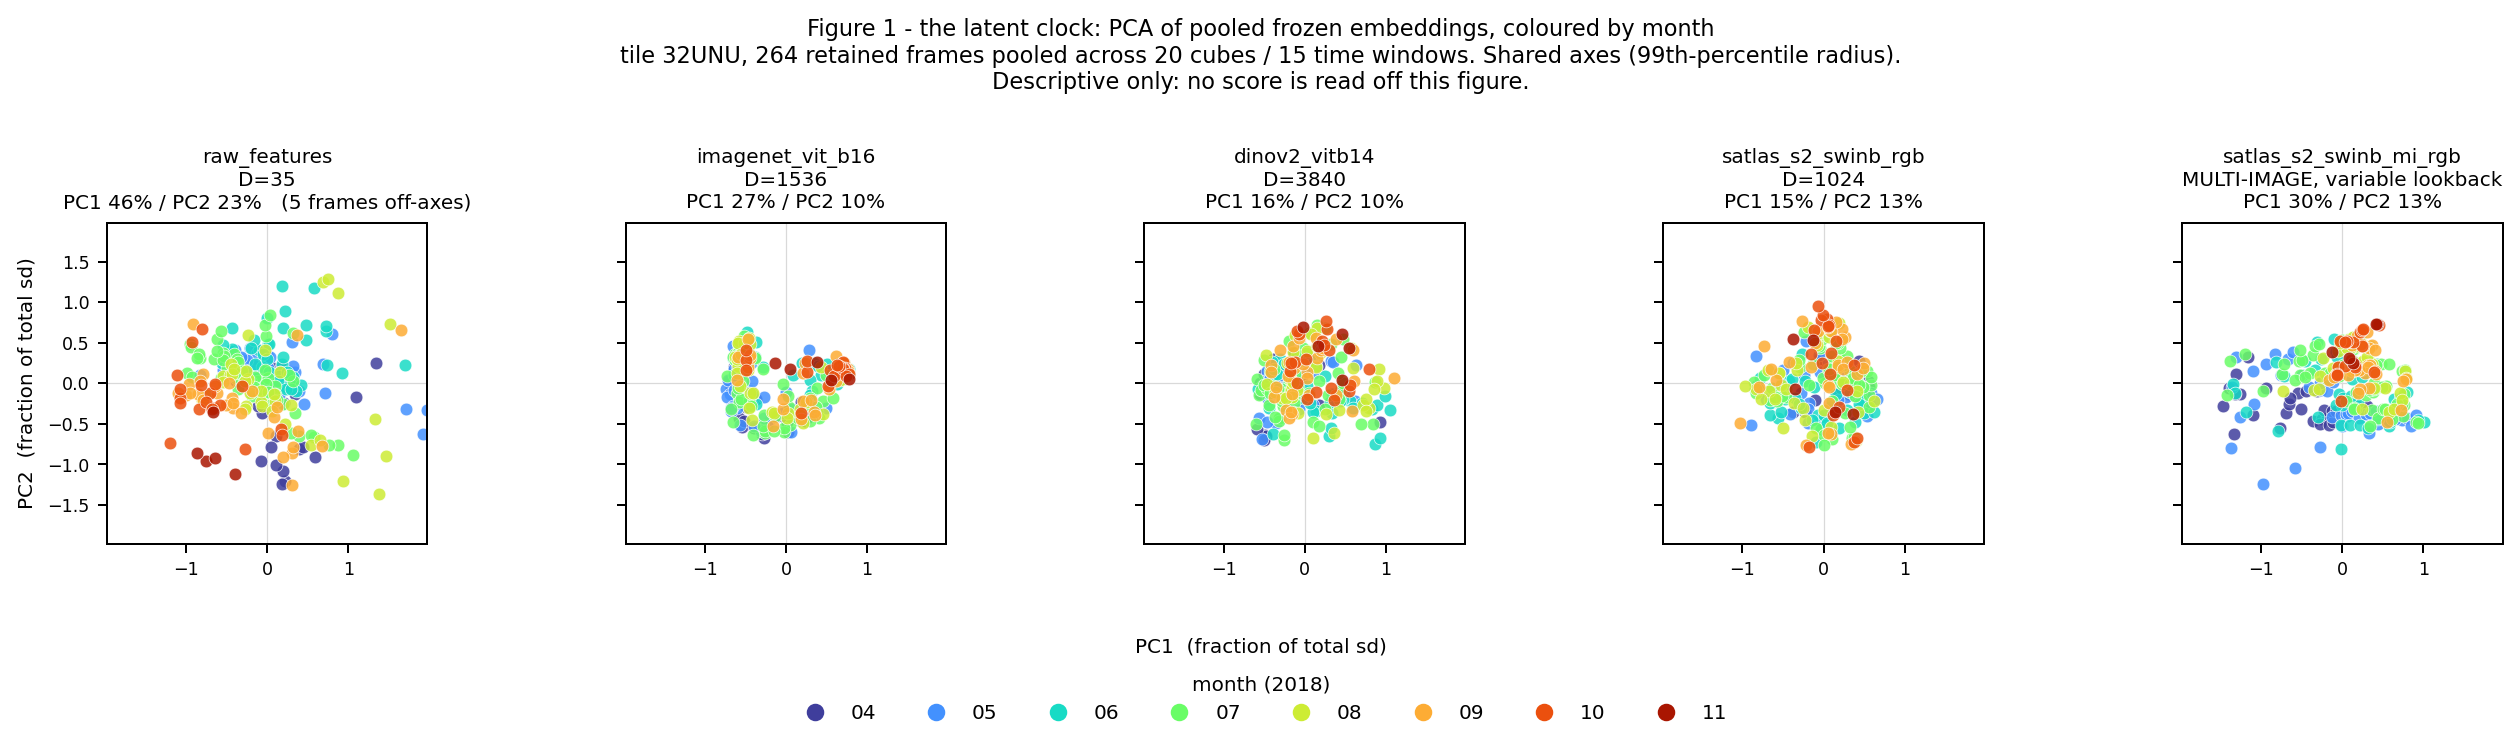

In [14]:
FIG = p1.figure1(MANIFEST, ARRAYS, out_path=os.path.join(FIGURES,
                                                         "figure1_latent_clock.png"))
from IPython.display import Image, display
display(Image(filename=FIG))

## Step 15: Save, and list what this phase wrote

One CSV, one PNG, both under `data/phase1_4/`. The CSV is read back and
re-asserted rather than trusted.

In [15]:
CSV = os.path.join(RESULTS, "p1_appearance_results.csv")
RESULTS_DF.to_csv(CSV, index=False)
print(f"[phase1_4] {os.path.basename(CSV)}: {RESULTS_DF.shape} "
      f"({os.path.getsize(CSV) / 1e3:.0f} kB)")

back = pd.read_csv(CSV)
assert back.shape == RESULTS_DF.shape, (back.shape, RESULTS_DF.shape)
p1.assert_results_complete(back)
print(f"\nre-read and re-asserted: {len(back)} rows, "
      f"{back.encoder.nunique()} encoder labels, "
      f"{sorted(back.feature_set.unique())}")
print(f"columns ({len(back.columns)}): {list(back.columns)}")

print()
describe_phase(PHASE)
print()
for root, dirs, files in os.walk(os.path.join(REPO, "data", PHASE)):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"  {os.path.getsize(p) / 1e3:>8.1f} kB  "
              f"{os.path.relpath(p, REPO)}")

[phase1_4] p1_appearance_results.csv: (192, 45) (164 kB)
[p1] results table COMPLETE: 192 rows, 6 encoder labels x 4 feature sets x 3 fold modes x 2 targets x 2 estimators

re-read and re-asserted: 192 rows, 6 encoder labels, ['degenerate', 'grid_cell', 'pooled', 'raw_pooled']
columns (45): ['target', 'fold_mode', 'estimator', 'encoder', 'feature_set', 'feature_level', 'wsd_bin', 'n_feature_rows', 'n_manifest_rows', 'D', 'n_classes_realised', 'chance_balanced_accuracy', 'chance_macro_f1', 'majority_class', 'majority_frac', 'si_comparable', 'note', 'n_folds', 'balanced_accuracy_mean', 'balanced_accuracy_std', 'balanced_accuracy_min', 'balanced_accuracy_max', 'balanced_accuracy_spread', 'per_fold_balanced_accuracy', 'macro_f1_mean', 'macro_f1_std', 'macro_f1_min', 'macro_f1_max', 'macro_f1_spread', 'per_fold_macro_f1', 'dummy_balanced_accuracy_mean', 'dummy_balanced_accuracy_std', 'dummy_balanced_accuracy_min', 'dummy_balanced_accuracy_max', 'dummy_balanced_accuracy_spread', 'per_fold_du

## Phase 1.4 is done when

- [ ] Step 5 green: the full suite passes, including the five P1 assertions.
- [ ] Step 7 printed the **realised** class distribution and derived chance from
      it — not 1/12 for month, not 1/4 for season.
- [ ] Step 8 asserted all 20 × 5 (cube, encoder) pairs present at the current
      schema, and re-asserted the join independently of `cv.join_embeddings`.
- [ ] Step 9 re-derived fold disjointness from the manifest, importing nothing
      from `probes.cv`.
- [ ] Step 10 showed the selected C identical on every fold under a poisoned
      test set, while the test score moved.
- [ ] Step 11 produced the results table: 5 encoders × 4 feature sets × 3 fold
      modes × 2 targets × 2 estimators, each with balanced accuracy, macro-F1,
      the dummy floor, and the across-fold spread.
- [ ] Step 12 asserted the baseline row and the degenerate control are present,
      and printed what the degenerate control actually scores.
- [ ] Step 13 reported the rank agreement between the three fold modes.
- [ ] Step 14 rendered Figure 1 for all five encoders on shared axes.
- [ ] Step 15 wrote one CSV and one PNG under `data/phase1_4/`, read the CSV
      back, and re-asserted it.

**Undo.** `reset_phase("phase1_4")` clears exactly this phase; `data/raw` and
every other phase are untouched. Deleting the `phase1_4/` Drive subfolder is the
coarser version of the same undo.

**What a P1 "pass" does and does not license.** It licenses P2 and P3: the
appearance signal a dynamics probe would build on is present and measurable. It
does not license any claim about dynamics, forecastability, or representation
quality — month is confounded with appearance, which is the whole reason this
probe is calibration and not a finding.